In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("data/customer_churn.csv")

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,City,SignupDate,Churn
0,CUST-1621,Female,0.0,yes,N,57.0,No,No,Fiber optic,month-to-month,no,Mailed check,108.70,5953.2,bengaluru,22-05-2021,No
1,CUST-2087,FEMALE,0.0,No,Yes,71.0,Yes,No,No,NaN,YES,Electronic check,62.26,4316.57,Delhi,07-12-2023,No
2,CUST-1172,Male,1.0,No,No,23.0,No,No,DSL,Two year,No,Mailed check,88.92,2026.92,Bengaluru,09-12-2018,1
3,CUST-1473,Male,1.0,No,N,24.0,Yes,Yes,Fiber optic,Month-to-month,No,NaN,17.31,407.02,Chennai,31-07-2020,NO
4,CUST-1189,Male,0.0,Yes,No,19.0,Yes,No phone service,DSL,Month-to-month,No,Bank transfer,87.08,1647.09,Mumbai,12-01-2019,NO


customerID --> unique id given to every customer

SeniorCitizen --> 1 = senior citizen , 0 = not a senior citizen

Partner --> whether the customer has a partner (Yes/No)

Dependents --> whether the customer has dependents (Yes/No)

tenure --> no_of months the customer has stayed with the company

PhoneService/MultipleLines/InternetService --> services subscribed by customer

Contract --> type of contract (Month-to-month/One year/Two year)

PaperlessBilling --> whether billing is paperless (Yes/No)

PaymentMethod --> mode of payment

MonthlyCharges --> amount charged to the customer monthly

TotalCharges --> total amount charged to the customer

Churn --> target column , whether the customer left the company (Yes/No)

In [10]:
df.shape #Gives the shape of the dataframe in the form of rows and cols

(1120, 17)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1120 entries, 0 to 1119
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1120 non-null   str    
 1   gender            1057 non-null   str    
 2   SeniorCitizen     998 non-null    float64
 3   Partner           1010 non-null   str    
 4   Dependents        1008 non-null   str    
 5   tenure            1095 non-null   float64
 6   PhoneService      1120 non-null   str    
 7   MultipleLines     1015 non-null   str    
 8   InternetService   987 non-null    str    
 9   Contract          1008 non-null   str    
 10  PaperlessBilling  1120 non-null   str    
 11  PaymentMethod     1028 non-null   str    
 12  MonthlyCharges    1120 non-null   float64
 13  TotalCharges      1120 non-null   str    
 14  City              1006 non-null   str    
 15  SignupDate        1120 non-null   str    
 16  Churn             1120 non-null   str    
dtypes: flo

# DATA CLEANING

In [12]:
df.duplicated().sum() 
#duplicated()-->tells us how many rows are duplicated ,returntype Boolean and sum()-->counts the summation of the total no. of duplicated rows

np.int64(20)

In [13]:
df=df.drop_duplicates() #Remove repeated records
df=df.reset_index(drop=True) 
#reset_index()-->for creating a new sequential index starting from 0 and drop=True-->The old index is removed, and only the new index is kept.
#If we don't do drop=True then the old index will be remain as a old column and new index will be another column,hence it will be creating confusion.
df.shape

(1100, 17)

In [14]:
df['customerID'].duplicated().sum()
# no duplicate customer ids.

np.int64(0)

In [15]:
df.isna().sum()
#isna()--->checks every cell in the DataFrame,a value is missing (NaN, None, etc.) -> True or a value is present -> False

customerID            0
gender               62
SeniorCitizen       120
Partner             108
Dependents          108
tenure               25
PhoneService          0
MultipleLines       101
InternetService     133
Contract            109
PaperlessBilling      0
PaymentMethod        90
MonthlyCharges        0
TotalCharges          0
City                113
SignupDate            0
Churn                 0
dtype: int64

In [16]:
df['gender']=df['gender'].str.strip().str.lower()
#.str-->allows us to apply string methods to every value in a Pandas Series (column).
#.strip()-->it is used to remove spaces from front and back
#.lower()-->it is used to convert the entire into lowercase

df['gender']=df['gender'].replace({'male':'Male','female':'Female'})
#.replace()-->Replace entire values

df['gender'].unique()
#.unique()-->It only shows the distinct values.

<ArrowStringArray>
['Female', 'Male', nan]
Length: 3, dtype: str

In [17]:
df['gender'].value_counts()
#used to count how many times each unique value appears in a column.

gender
Male      580
Female    458
Name: count, dtype: int64

In [18]:
df['Partner']=df['Partner'].str.strip().str.lower()
df['Partner']=df['Partner'].replace({'yes':'Yes','y':'Yes','no':'No','n':'No'})
df['Partner'].unique()

<ArrowStringArray>
['Yes', 'No', nan]
Length: 3, dtype: str

In [19]:
df['Partner'].value_counts()

Partner
Yes    517
No     475
Name: count, dtype: int64

In [20]:
df['Dependents']=df['Dependents'].str.strip().str.lower()
df['Dependents']=df['Dependents'].replace({'yes':'Yes','y':'Yes','no':'No','n':'No'})
df['Dependents'].unique()

<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [21]:
df['Dependents'].value_counts()

Dependents
No     611
Yes    381
Name: count, dtype: int64

In [22]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,City,SignupDate,Churn
0,CUST-1621,Female,0.0,Yes,No,57.0,No,No,Fiber optic,month-to-month,no,Mailed check,108.70,5953.2,bengaluru,22-05-2021,No
1,CUST-2087,Female,0.0,No,Yes,71.0,Yes,No,No,NaN,YES,Electronic check,62.26,4316.57,Delhi,07-12-2023,No
2,CUST-1172,Male,1.0,No,No,23.0,No,No,DSL,Two year,No,Mailed check,88.92,2026.92,Bengaluru,09-12-2018,1
3,CUST-1473,Male,1.0,No,No,24.0,Yes,Yes,Fiber optic,Month-to-month,No,NaN,17.31,407.02,Chennai,31-07-2020,NO
4,CUST-1189,Male,0.0,Yes,No,19.0,Yes,No phone service,DSL,Month-to-month,No,Bank transfer,87.08,1647.09,Mumbai,12-01-2019,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,CUST-1919,Female,1.0,Yes,Yes,20.0,yes,No,DSL,month-to-month,No,Mailed check,69.07,1278.81,Hyderabad,06-01-2023,NO
1096,CUST-1211,Male,NaN,NaN,Yes,29.0,Yes,No,Fiber optic,NaN,Yes,Bank transfer,68.06,1930.99,Hyderabad,25-02-2019,No
1097,CUST-1502,Male,0.0,No,No,40.0,Yes,No phone service,Fiber optic,Month-to-month,Yes,Electronic check,51.74,1828.3,Hyderabad,27-09-2020,NO
1098,CUST-1537,Male,NaN,No,Yes,63.0,No,No,Fiber optic,Two year,Yes,Credit card,65.24,4013.91,NaN,06-12-2020,No


In [23]:
df['PhoneService']=df['PhoneService'].str.strip().str.lower().replace({'yes':'Yes','no':'No'})
#.str.strip()-->means when we have an entire DataFrame column, it's a Pandas Series, not a single string.The method applies on every element of the col.

df['PaperlessBilling']=df['PaperlessBilling'].str.strip().str.lower().replace({'yes':'Yes','no':'No'})

df['InternetService']=df['InternetService'].str.strip().str.lower().replace({'dsl':'DSL','fiber optic':'Fiber optic','no':'No'})

df['Contract']=df['Contract'].str.strip().str.lower().replace({'month-to-month':'Month-to-month','one year':'One year','two year':'Two year'})

df['PaymentMethod']=df['PaymentMethod'].str.strip()

df['City']=df['City'].str.strip().str.lower().str.title()
#.str.title()-->Capitalize the first letter of each word.

def get_unique(x):
    return x.unique()

df[['PhoneService','PaperlessBilling','InternetService','Contract']].apply(get_unique)
#.apply()-->It is a Pandas method to take each column one by one and perform the function on it.
#Since axis=0 is the default, it processes columns, not rows.

PhoneService                                        [No, Yes]
PaperlessBilling                                    [No, Yes]
InternetService                   [Fiber optic, No, DSL, nan]
Contract            [Month-to-month, nan, Two year, One year]
dtype: object

In [24]:
# fixing target column Churn (mixed labels Yes/No/1/0/yes/NO)
df['Churn']=df['Churn'].astype(str).str.strip().str.lower()
#.astype(str)-->everything is converted to string type
df['Churn']=df['Churn'].replace({'yes':'Yes','1':'Yes','no':'No','0':'No'})
df['Churn'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [25]:
# SeniorCitizen is stored as mixed int/str (0,1,'0','1') --> converting it to int
df['SeniorCitizen']=pd.to_numeric(df['SeniorCitizen'],errors='coerce')
#pd.to_numeric()-->this converts values to numbers
#errors='coerce'-->If a value cannot be converted into a number, don't throw an error. Instead, replace it with NaN (missing value)

In [26]:
df['tenure'] 
#Select only the tenure column.

0       57.0
1       71.0
2       23.0
3       24.0
4       19.0
        ... 
1095    20.0
1096    29.0
1097    40.0
1098    63.0
1099     8.0
Name: tenure, Length: 1100, dtype: float64

In [27]:
df.loc[df['tenure']<0,'tenure']=np.nan
#df['tenure']<0 -->Check whether each value is negative.
#df.loc[rows, columns]-->rows=df['tenure']<0,cols='tenure'
#loc lets us to update only the rows that match a condition

In [28]:
# TotalCharges is stored as object because of blank ' ' strings --> convert to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].isna().sum()
#isna()-->checks every value and returns:True → Missing value (NaN),False → Not missing

np.int64(15)

In [29]:
df.dtypes
#numerical cols-median
#categorical cols(text)-mode

customerID              str
gender                  str
SeniorCitizen       float64
Partner                 str
Dependents              str
tenure              float64
PhoneService            str
MultipleLines           str
InternetService         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
City                    str
SignupDate              str
Churn                   str
dtype: object

In [30]:
t=df['tenure'].median()
#median()--> finds the middle value after sorting the data.

tc=df['TotalCharges'].median()

sc=df['SeniorCitizen'].mode()[0]
#mode() returns the most frequent value(s) in the column.
#mode() always returns a Series, even if there's only one mode.
#we used [0] to get the first mode

p=df['Partner'].mode()[0]
#Finding the most frequently occurring value in the Partner column and store it in the variable p
#[0]-->extracts the first value from that Series.

d=df['Dependents'].mode()[0]
g=df['gender'].mode()[0]
ml=df['MultipleLines'].mode()[0]
isv=df['InternetService'].mode()[0]
c=df['Contract'].mode()[0]
pm=df['PaymentMethod'].mode()[0]
ci=df['City'].mode()[0]

cols=['tenure','TotalCharges','SeniorCitizen','Partner','Dependents','gender',
      'MultipleLines','InternetService','Contract','PaymentMethod','City']
vals=[t,tc,sc,p,d,g,ml,isv,c,pm,ci]

for col,val in zip(cols,vals):
    df[col]=df[col].fillna(val)

In [31]:
df[col]

0       Bengaluru
1           Delhi
2       Bengaluru
3         Chennai
4          Mumbai
          ...    
1095    Hyderabad
1096    Hyderabad
1097    Hyderabad
1098    Bengaluru
1099        Delhi
Name: City, Length: 1100, dtype: str

In [32]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
City                0
SignupDate          0
Churn               0
dtype: int64

In [33]:
df['SeniorCitizen']=df['SeniorCitizen'].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1100 non-null   str    
 1   gender            1100 non-null   str    
 2   SeniorCitizen     1100 non-null   int64  
 3   Partner           1100 non-null   str    
 4   Dependents        1100 non-null   str    
 5   tenure            1100 non-null   float64
 6   PhoneService      1100 non-null   str    
 7   MultipleLines     1100 non-null   str    
 8   InternetService   1100 non-null   str    
 9   Contract          1100 non-null   str    
 10  PaperlessBilling  1100 non-null   str    
 11  PaymentMethod     1100 non-null   str    
 12  MonthlyCharges    1100 non-null   float64
 13  TotalCharges      1100 non-null   float64
 14  City              1100 non-null   str    
 15  SignupDate        1100 non-null   str    
 16  Churn             1100 non-null   str    
dtypes: flo

observation

1. 20 fully duplicated rows were removed.
2. gender,Partner,Dependents,PhoneService,InternetService,Contract,PaperlessBilling had inconsistent casing/short-forms(e.g. 'y'/'n','yes'/'YES') which were standardized.
3. tenure had a few negative values which were treated as invalid and replaced along with the actual missing values using median.
4. TotalCharges was an object column because of blank strings(' ') , converted to numeric and missing values filled with median.
5. SeniorCitizen was stored as a mix of int/str , converted to a clean int column.
6. Remaining missing values in categorical columns were filled using mode.

# DATA TRANSFORMATION / MANIPULATION

In [34]:
df['MonthlyCharges']=df['MonthlyCharges'].round(2)
df['TotalCharges']=df['TotalCharges'].round(2)

In [35]:
df['SignupDate']=pd.to_datetime(df['SignupDate'],format='%d-%m-%Y')
#pd.to_datetime()-->converts text to date time object

df['signup_year']=df['SignupDate'].dt.year
#Extracting only the year from the SignupDate column and create a new column called signup_year

In [36]:
df['tenure']=df['tenure'].round(0).astype(int)

df['tenure_category']=pd.cut(df['tenure'],bins=[-1,6,12,24,48,72],
                              labels=['0-6mo','7-12mo','1-2yr','2-4yr','4-6yr'])
#pd.cut() means:Dividing continuous numerical data into intervals (bins).
#by default, pd.cut() creates intervals that are open on the left and closed on the right:(0,6])

In [37]:
df[['tenure','tenure_category']].head(10)

,tenure,tenure_category
0,57,4-6yr
1,71,4-6yr
2,23,1-2yr
3,24,1-2yr
4,19,1-2yr
5,24,1-2yr
6,23,1-2yr
7,8,7-12mo
8,4,0-6mo
9,57,4-6yr


In [38]:
def sc_label(cell):
    if cell==1:
        return 'Senior'
    else:
        return 'Non-Senior'

df['SeniorCitizen']=df['SeniorCitizen'].apply(sc_label)

#apply() means:Run the sc_label() function on every value in the SeniorCitizen column.

In [39]:
df['SeniorCitizen'].head()

0    Non-Senior
1    Non-Senior
2        Senior
3        Senior
4    Non-Senior
Name: SeniorCitizen, dtype: str

In [40]:
avg_charge=(df['TotalCharges']/df['tenure'].replace(0,1)).round(2)
df['avg_monthly_spend']=avg_charge

In [41]:
def value_seg(cell):
    if cell<35:
        return 'Low'
    elif cell<70:
        return 'Medium'
    else:
        return 'High'

df['spend_segment']=df['MonthlyCharges'].apply(value_seg)

#cell represents one value from the MonthlyCharges column
#Here we r segregating the customers into 3 categories - 'Low','Medium','High'

In [42]:
df[['MonthlyCharges', 'spend_segment']].head()

,MonthlyCharges,spend_segment
0,108.70,High
1,62.26,Medium
2,88.92,High
3,17.31,Low
4,87.08,High


In [43]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'City', 'SignupDate', 'Churn', 'signup_year',
       'tenure_category', 'avg_monthly_spend', 'spend_segment'],
      dtype='str')

In [44]:
new_order=['customerID','gender','SeniorCitizen','Partner','Dependents','City',
           'SignupDate','signup_year','tenure','tenure_category',
           'PhoneService','MultipleLines','InternetService','Contract',
           'PaperlessBilling','PaymentMethod',
           'MonthlyCharges','avg_monthly_spend','spend_segment','TotalCharges','Churn']

df=df[new_order]

In [45]:
df=df.sort_values(by='customerID',ascending=True)
#.sort_values()-->sort the rows
#by='customerID'-->customerID column for sorting.
df=df.reset_index(drop=True)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,City,SignupDate,signup_year,tenure,tenure_category,...,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,avg_monthly_spend,spend_segment,TotalCharges,Churn
0,CUST-1000,Female,Non-Senior,Yes,No,Chennai,2018-01-01,2018,49,4-6yr,...,No,DSL,One year,Yes,Electronic check,55.98,56.48,Medium,2767.71,Yes
1,CUST-1001,Female,Non-Senior,Yes,No,Mumbai,2018-01-02,2018,58,4-6yr,...,Yes,Fiber optic,Month-to-month,Yes,Electronic check,131.50,132.62,High,7691.88,Yes
2,CUST-1002,Male,Non-Senior,No,No,Mumbai,2018-01-04,2018,56,4-6yr,...,No,DSL,Month-to-month,Yes,Electronic check,15.00,14.21,Low,795.50,No
3,CUST-1003,Male,Senior,Yes,No,Delhi,2018-01-06,2018,54,4-6yr,...,No phone service,No,Month-to-month,Yes,Bank transfer,30.18,30.68,Low,1656.76,No
4,CUST-1004,Male,Non-Senior,No,Yes,Hyderabad,2018-01-08,2018,37,2-4yr,...,Yes,Fiber optic,Two year,No,Electronic check,71.07,75.32,High,2786.99,Yes


# Data analysis

In [46]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,City,SignupDate,signup_year,tenure,tenure_category,...,MultipleLines,InternetService,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,avg_monthly_spend,spend_segment,TotalCharges,Churn
0,CUST-1000,Female,Non-Senior,Yes,No,Chennai,2018-01-01,2018,49,4-6yr,...,No,DSL,One year,Yes,Electronic check,55.98,56.48,Medium,2767.71,Yes
1,CUST-1001,Female,Non-Senior,Yes,No,Mumbai,2018-01-02,2018,58,4-6yr,...,Yes,Fiber optic,Month-to-month,Yes,Electronic check,131.50,132.62,High,7691.88,Yes
2,CUST-1002,Male,Non-Senior,No,No,Mumbai,2018-01-04,2018,56,4-6yr,...,No,DSL,Month-to-month,Yes,Electronic check,15.00,14.21,Low,795.50,No
3,CUST-1003,Male,Senior,Yes,No,Delhi,2018-01-06,2018,54,4-6yr,...,No phone service,No,Month-to-month,Yes,Bank transfer,30.18,30.68,Low,1656.76,No
4,CUST-1004,Male,Non-Senior,No,Yes,Hyderabad,2018-01-08,2018,37,2-4yr,...,Yes,Fiber optic,Two year,No,Electronic check,71.07,75.32,High,2786.99,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,CUST-2095,Female,Senior,Yes,No,Delhi,2023-12-23,2023,57,4-6yr,...,No,No,One year,Yes,Credit card,63.27,68.20,Medium,3887.42,No
1096,CUST-2096,Male,Non-Senior,No,Yes,Chennai,2023-12-25,2023,58,4-6yr,...,No,Fiber optic,One year,Yes,Mailed check,33.34,33.07,Low,1917.84,No
1097,CUST-2097,Female,Non-Senior,No,No,Bengaluru,2023-12-27,2023,47,2-4yr,...,No,Fiber optic,Month-to-month,No,Mailed check,16.76,17.85,Low,838.90,Yes
1098,CUST-2098,Male,Non-Senior,No,Yes,Chennai,2023-12-29,2023,47,2-4yr,...,Yes,DSL,One year,Yes,Electronic check,55.35,55.28,Medium,2598.29,Yes


1. Find the total no_of_customers

In [47]:
df.shape[0]

1100

2. get the overall churn rate

In [48]:
(df['Churn']=='Yes').mean().round(2)

np.float64(0.35)

observation: about 27% of the customers have churned

3. get the gender wise no_of_customers

In [49]:
df['gender'].value_counts()

gender
Male      642
Female    458
Name: count, dtype: int64

4. get the gender wise churn rate

In [50]:
df.groupby('gender')['Churn'].apply(lambda x:(x=='Yes').mean()).round(2)
#df.groupby('gender')-->This splits the data into 2 groups

gender
Female    0.34
Male      0.35
Name: Churn, dtype: float64

observation: churn rate is almost similar in both genders

5. get the contract wise no_of_customers

In [51]:
df['Contract'].value_counts()

Contract
Month-to-month    635
Two year          238
One year          227
Name: count, dtype: int64

6. get the contract wise churn rate

In [52]:
df.groupby('Contract')['Churn'].apply(lambda x:(x=='Yes').mean()).round(2).sort_values(ascending=False)

Contract
Two year          0.38
One year          0.35
Month-to-month    0.33
Name: Churn, dtype: float64

observation: Two year contract customers are churning the most compared to one year and month-to-month contract customers

7. get the senior citizen wise churn rate

In [53]:
df.groupby('SeniorCitizen')['Churn'].apply(lambda x:(x=='Yes').mean()).round(2)

SeniorCitizen
Non-Senior    0.36
Senior        0.31
Name: Churn, dtype: float64

observation: The churn rate is higher among non-senior customers, indicating younger customers may switch services more frequently compared to senior customers.

8. get the internet service wise churn rate

In [54]:
df.groupby('InternetService')['Churn'].apply(lambda x:(x=='Yes').mean()).round(2).sort_values(ascending=False)

InternetService
No             0.37
DSL            0.34
Fiber optic    0.34
Name: Churn, dtype: float64

observation: Customers without internet service show the highest churn rate, while DSL and Fiber optic users have similar churn patterns, indicating service type has an impact on customer retention.

9. get the payment method wise churn rate

In [55]:
df.groupby('PaymentMethod')['Churn'].apply(lambda x:(x=='Yes').mean()).round(2).sort_values(ascending=False)

PaymentMethod
Credit card         0.37
Bank transfer       0.35
Mailed check        0.35
Electronic check    0.33
Name: Churn, dtype: float64

observation: customers paying through credit card churn the most

10. get the tenure_category wise churn rate

In [56]:
df.groupby('tenure_category',observed=True)['Churn'].apply(lambda x:(x=='Yes').mean()).round(2)

tenure_category
0-6mo     0.38
7-12mo    0.39
1-2yr     0.37
2-4yr     0.35
4-6yr     0.31
Name: Churn, dtype: float64

observation: newly joined customers(0-6mo) churn the most , churn rate decreases as tenure increases

11. get the spend_segment wise no_of_customers and churn rate

In [57]:
df.groupby('spend_segment',observed=True).agg(no_of_customers=('customerID','count'),
                                     churn_rate=('Churn',lambda x:(x=='Yes').mean().round(2)))

,no_of_customers,churn_rate
spend_segment,,
High,438,0.34
Low,162,0.33
Medium,500,0.36


observation: Low spend_segment customers show a higher churn rate compared to High/medium spend customers

12. get the city wise no_of_customers

In [58]:
df['City'].value_counts()

City
Bengaluru    422
Mumbai       268
Hyderabad    146
Chennai      132
Delhi        132
Name: count, dtype: int64

13. get the paperless billing wise churn rate

In [59]:
df.groupby('PaperlessBilling')['Churn'].apply(lambda x:(x=='Yes').mean()).round(2)

PaperlessBilling
No     0.35
Yes    0.34
Name: Churn, dtype: float64

observation: customers without paperless billing churn slightly more than customers with paperless billing

14. get the correlation between tenure,MonthlyCharges,TotalCharges

In [60]:
df[['tenure','MonthlyCharges','TotalCharges']].corr().round(2)
#.corr()-->This calculates correlation between columns.

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,-0.05,0.73
MonthlyCharges,-0.05,1.00,0.52
TotalCharges,0.73,0.52,1.00


observation

tenure and TotalCharges are having strong positive correlation(as tenure increases , total_charges also increases)

tenure and MonthlyCharges are having very weak correlation

15. get the statistical description of numerical columns

In [61]:
df.describe()

,SignupDate,signup_year,tenure,MonthlyCharges,avg_monthly_spend,TotalCharges
count,1100,1100.000000,1100.000000,1100.000000,1100.000000,1100.000000
mean,2020-12-30 12:01:18.545454,2020.497273,36.110909,64.631818,61.895864,2234.388355
min,2018-01-01 00:00:00,2018.000000,0.000000,15.000000,-5.810000,-209.190000
25%,2019-07-01 18:00:00,2019.000000,19.000000,45.750000,42.182500,823.852500
50%,2020-12-30 12:00:00,2020.000000,36.000000,64.455000,62.920000,1885.090000
75%,2022-07-01 06:00:00,2022.000000,53.000000,81.012500,79.965000,3358.172500
max,2023-12-31 00:00:00,2023.000000,72.000000,342.240000,328.220000,15426.360000
std,NaN,1.708777,20.440029,28.180879,30.692993,1754.900762


observation

total 1100 customers are present after cleaning

1. tenure

average tenure of a customer is around 33 months with a fluctuation of 20 months(68% of customers have tenure between 13-53 months)

2. MonthlyCharges

average monthly charge is around 66 with a fluctuation of 27

3. TotalCharges

there is a huge gap between 75th percentile and max value , indicating presence of outliers in TotalCharges

16. get the no_of male and female customers who churned

In [62]:
df.groupby(['gender','Churn']).size().unstack()
#.size()-->Counts number of rows in each group.
#.unstack()-->This converts rows → columns.

Churn,No,Yes
gender,,
Female,302,156
Male,417,225


observation: male customers who churned are slightly higher in number compared to female customers

# VISUALS

C:\Users\ANUSHKA SAHA\AppData\Local\Temp\ipykernel_23512\2389441213.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df,x='Churn',palette=['green','red'])


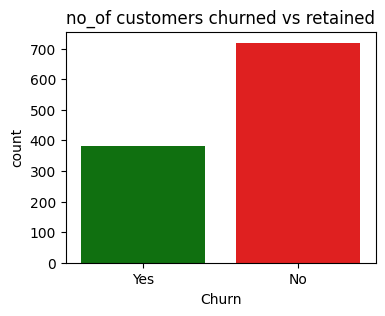

In [63]:
plt.figure(figsize=(4,3))
sns.countplot(df,x='Churn',palette=['green','red'])
plt.title('no_of customers churned vs retained')
plt.show()

observation: no_of retained customers is much higher than no_of churned customers

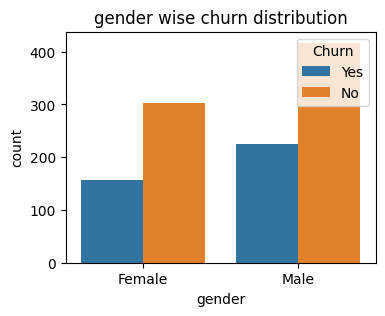

In [64]:
plt.figure(figsize=(4,3))
c=sns.countplot(df,x='gender',hue='Churn')
plt.title('gender wise churn distribution')
plt.show()

observation: churn count is nearly the same across both genders

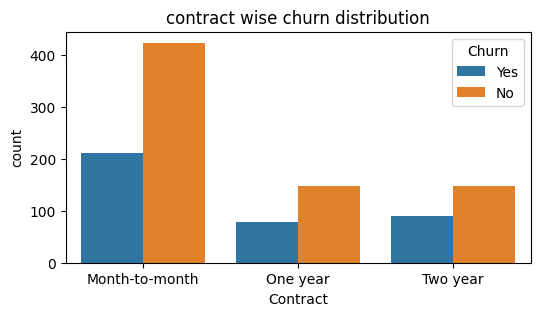

In [65]:
plt.figure(figsize=(6,3))
c=sns.countplot(df,x='Contract',hue='Churn',order=['Month-to-month','One year','Two year'])
plt.title('contract wise churn distribution')
plt.show()

observation: month-to-month contract customers churn the most , two year contract customers churn the least

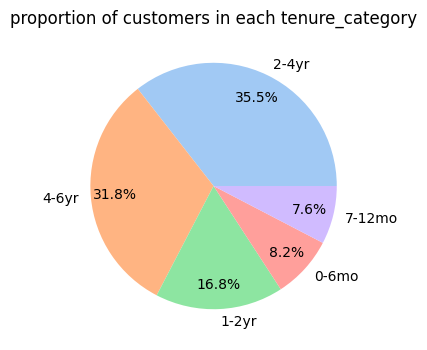

In [66]:
churn_cat=df['tenure_category'].value_counts()
v=churn_cat.values
l=churn_cat.index

plt.figure(figsize=(4,4))
plt.pie(x=v,labels=l,autopct='%.1f%%',colors=sns.color_palette('pastel'),
        labeldistance=1.1,pctdistance=0.8)
plt.title('proportion of customers in each tenure_category')
plt.show()

observation: customers with 2-4yr and 4-6yr tenure make up the largest proportion of the customer base

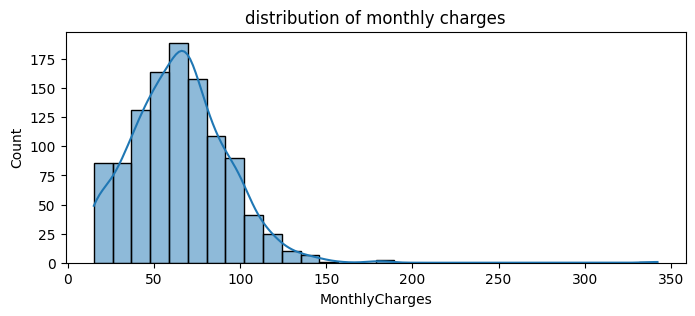

In [67]:
plt.figure(figsize=(8,3))
sns.histplot(df,x='MonthlyCharges',bins=30,kde=True) #kde=True-->Adds a smooth curve (Density Curve)
plt.title('distribution of monthly charges')
plt.show()

observation: monthly charges are slightly right-skewed with a few high value outliers

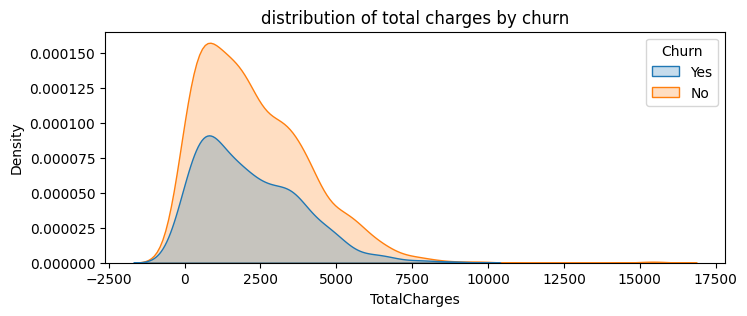

In [68]:
plt.figure(figsize=(8,3))
sns.kdeplot(df,x='TotalCharges',hue='Churn',fill=True)
plt.title('distribution of total charges by churn')
plt.show()

observation: churned customers are concentrated more towards lower total_charges , indicating they leave early(short tenure)

C:\Users\ANUSHKA SAHA\AppData\Local\Temp\ipykernel_23512\2501842266.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(df,x='Churn',y='MonthlyCharges',estimator='mean',errorbar=None,palette=['green','red'])


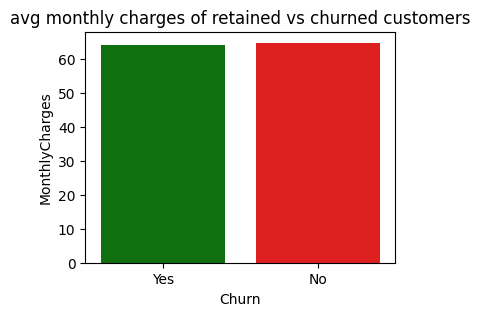

In [69]:
plt.figure(figsize=(4,3))
sns.barplot(df,x='Churn',y='MonthlyCharges',estimator='mean',errorbar=None,palette=['green','red'])
plt.title('avg monthly charges of retained vs churned customers')
plt.show()

observation: churned customers on average pay higher monthly charges compared to retained customers

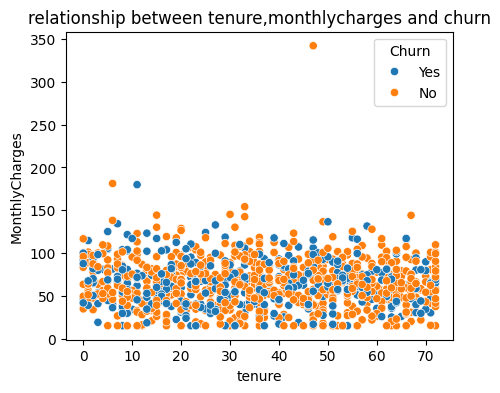

In [70]:
plt.figure(figsize=(5,4))
sns.scatterplot(df,x='tenure',y='MonthlyCharges',hue='Churn')
plt.title('relationship between tenure,monthlycharges and churn')
plt.show()

observation: churned customers are mostly concentrated in the low tenure , high monthly_charge region

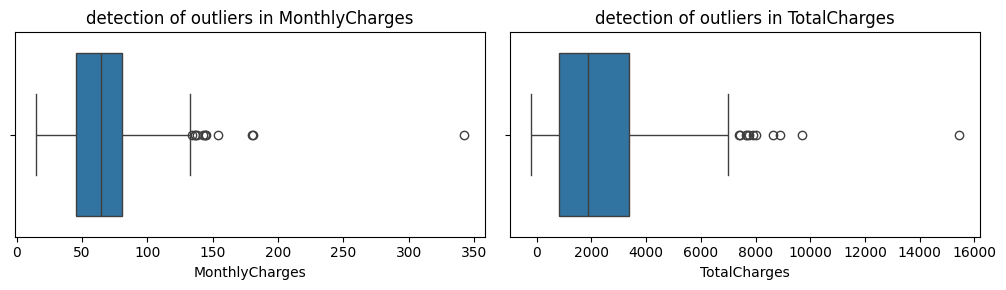

In [71]:
fig,axes=plt.subplots(ncols=2,figsize=(10,3))
sns.boxplot(df,x='MonthlyCharges',ax=axes[0])
sns.boxplot(df,x='TotalCharges',ax=axes[1])

axes[0].set_title('detection of outliers in MonthlyCharges')
axes[1].set_title('detection of outliers in TotalCharges')

plt.tight_layout()
plt.show()

observation: a few outliers are present in MonthlyCharges , TotalCharges shows no major outliers

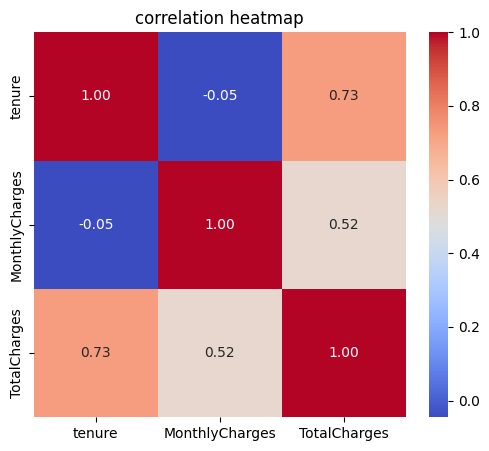

In [72]:
plt.figure(figsize=(6,5))
c=df[['tenure','MonthlyCharges','TotalCharges']].corr()
sns.heatmap(c,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation heatmap')
plt.show()

observation: tenure and TotalCharges show strong positive correlation(91%)

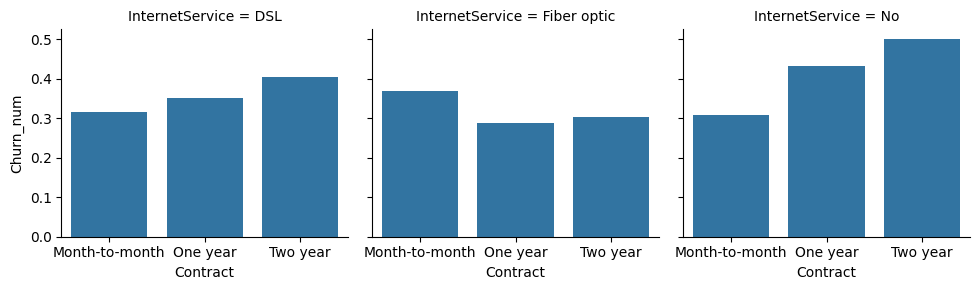

In [73]:
# Convert Yes/No into 1/0
df['Churn_num'] = df['Churn'].replace({'Yes':1,'No':0})

fg = sns.FacetGrid(df, col='InternetService', height=3, aspect=1.1)

fg.map_dataframe(
    sns.barplot,
    x='Contract',
    y='Churn_num',
    estimator='mean',
    errorbar=None,
    order=['Month-to-month','One year','Two year']
)

plt.show()

observation

within every internet_service type , month-to-month contract customers churn the most

fiber optic customers on month-to-month contracts show the highest churn rate overall

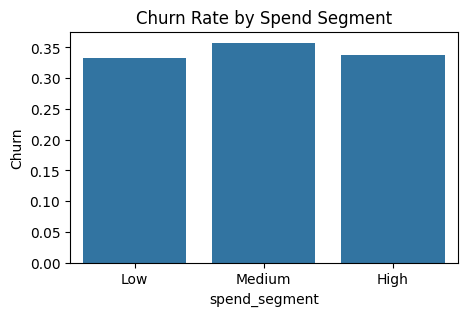

In [74]:
df['Churn'] = df['Churn'].map({'No':0,'Yes':1})

plt.figure(figsize=(5,3))
sns.barplot(
    data=df,
    x='spend_segment',
    y='Churn',
    order=['Low','Medium','High'],
    errorbar=None
)
plt.title('Churn Rate by Spend Segment')
plt.show()

observation: high spend_segment customers churn at a noticeably higher rate than low/medium spend customers

# conclusion

1. out of 1100 customers, about 27% have churned.

2. contract type is one of the strongest drivers of churn - month-to-month customers churn far more than one year/two year customers.

3. customers in the early stage of their relationship with the company(0-6 months tenure) are at the highest risk of churning; churn risk decreases as tenure increases.

4. senior citizens , fiber-optic internet users, high spend_segment customers and electronic-check payers show above-average churn rates and can be treated as high-risk customer groups.

5. churned customers on average pay higher monthly charges but have lower total_charges(because of shorter tenure), confirming that customers are leaving early despite paying more.

6. gender does not show a meaningful impact on churn.

7. the company should focus retention efforts on new(low-tenure), high-paying, month-to-month customers to reduce overall churn.